<a href="https://colab.research.google.com/github/CarlosWinicius/Analise-do-Remanejamento-UPE-CARUARU/blob/main/Analise_do_Remanejamento_UPE_CARUARU.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
import pandas as pd
import io

print()
uploaded = files.upload()

# Carregar o arquivo para um DataFrame
nome_arquivo = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[nome_arquivo]))

print(f"\n✓ Arquivo '{nome_arquivo}' carregado com sucesso!")
print(f"Total de registros: {len(df)}")


Saving base de dados tratada - base de dados tratada (1).csv to base de dados tratada - base de dados tratada (1) (2).csv

✓ Arquivo 'base de dados tratada - base de dados tratada (1) (2).csv' carregado com sucesso!
Total de registros: 3246


LIMPEZA DOS DADOS E PADRONIZAÇÃO

In [ ]:
# 1. Remover espaços extras nos nomes das colunas
df.columns = df.columns.str.strip()

# 2. Padronizar a coluna 'Entrada' (Garantir SISU e SSA limpos)
df['Entrada'] = df['Entrada'].str.strip().str.upper()

# 3. Criar Modalidade Simplificada (Ampla ou Cotista)
# Usando a coluna 'Categoria_Modalidade' que já parece estar bem definida
df['Modalidade_Simples'] = df['Categoria_Modalidade'].apply(
    lambda x: 'Cotista' if 'Cotista' in str(x) else 'Ampla'
)

# 4. Garantir que 'Ano' seja inteiro
df['Ano'] = pd.to_numeric(df['Ano'], errors='coerce').fillna(0).astype(int)

# 5. Filtrar apenas os Remanejáveis para esta análise
# O status na sua base é 'REMANEJÁVEL'
df_rem = df[df['Status_Resultado'] == 'REMANEJÁVEL'].copy()

print("\n✓ Limpeza da nova base concluída!")
print(f"Total de candidatos remanejáveis encontrados: {len(df_rem)}")


✓ Limpeza da nova base concluída!
Total de candidatos remanejáveis encontrados: 2052


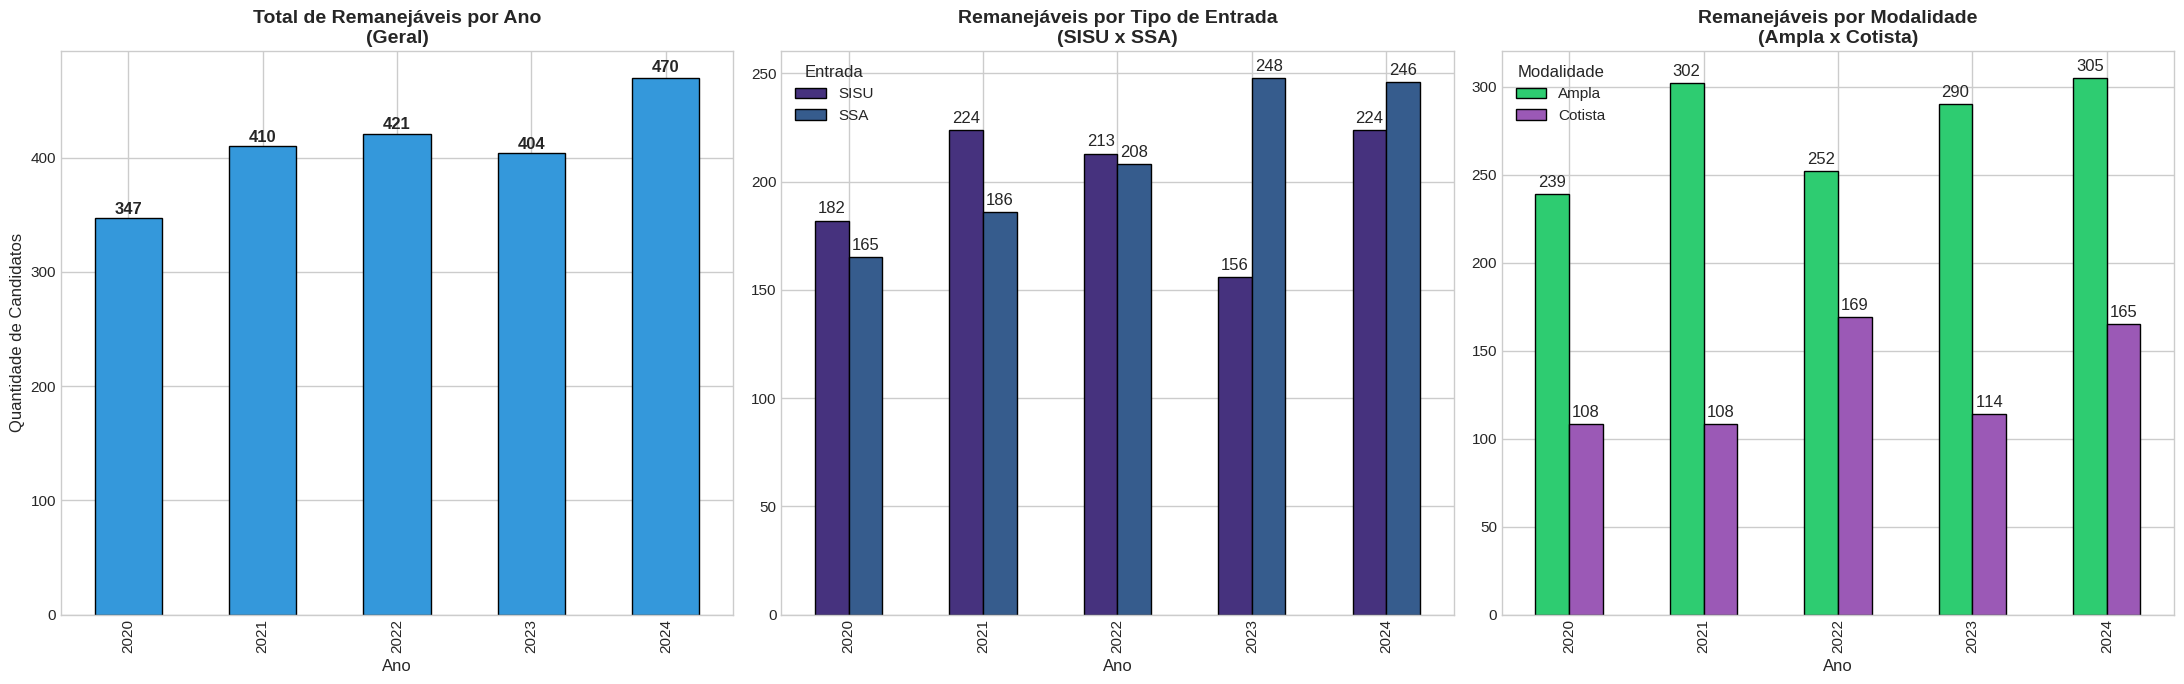

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração visual profissional
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("viridis")

def gerar_graficos_remanejaveis(dados):
    if dados.empty:
        print("Atenção: Não foram encontrados dados de 'REMANEJÁVEL' para gerar os gráficos.")
        return

    # Criar figura com 3 subplots
    fig, axes = plt.subplots(1, 3, figsize=(22, 7))

    # --- GRÁFICO 1: TOTAL POR ANO (TODOS) ---
    todos = dados.groupby('Ano').size()
    todos.plot(kind='bar', ax=axes[0], color='#3498db', edgecolor='black')
    axes[0].set_title('Total de Remanejáveis por Ano\n(Geral)', fontsize=14, fontweight='bold')
    axes[0].set_ylabel('Quantidade de Candidatos')
    axes[0].set_xlabel('Ano')
    for i, v in enumerate(todos):
        axes[0].text(i, v + (v*0.01), str(v), ha='center', fontweight='bold')

    # --- GRÁFICO 2: POR ENTRADA (SISU x SSA) ---
    por_entrada = dados.groupby(['Ano', 'Entrada']).size().unstack(fill_value=0)
    por_entrada.plot(kind='bar', ax=axes[1], edgecolor='black')
    axes[1].set_title('Remanejáveis por Tipo de Entrada\n(SISU x SSA)', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Ano')
    axes[1].legend(title='Entrada')
    for container in axes[1].containers:
        axes[1].bar_label(container, padding=3)

    # --- GRÁFICO 3: POR MODALIDADE (AMPLA x COTISTA) ---
    por_modalidade = dados.groupby(['Ano', 'Modalidade_Simples']).size().unstack(fill_value=0)
    por_modalidade.plot(kind='bar', ax=axes[2], color=['#2ecc71', '#9b59b6'], edgecolor='black')
    axes[2].set_title('Remanejáveis por Modalidade\n(Ampla x Cotista)', fontsize=14, fontweight='bold')
    axes[2].set_xlabel('Ano')
    axes[2].legend(title='Modalidade')
    for container in axes[2].containers:
        axes[2].bar_label(container, padding=3)

    plt.tight_layout()
    plt.show()

# Executar a geração dos gráficos
gerar_graficos_remanejaveis(df_rem)

Desconsiderados


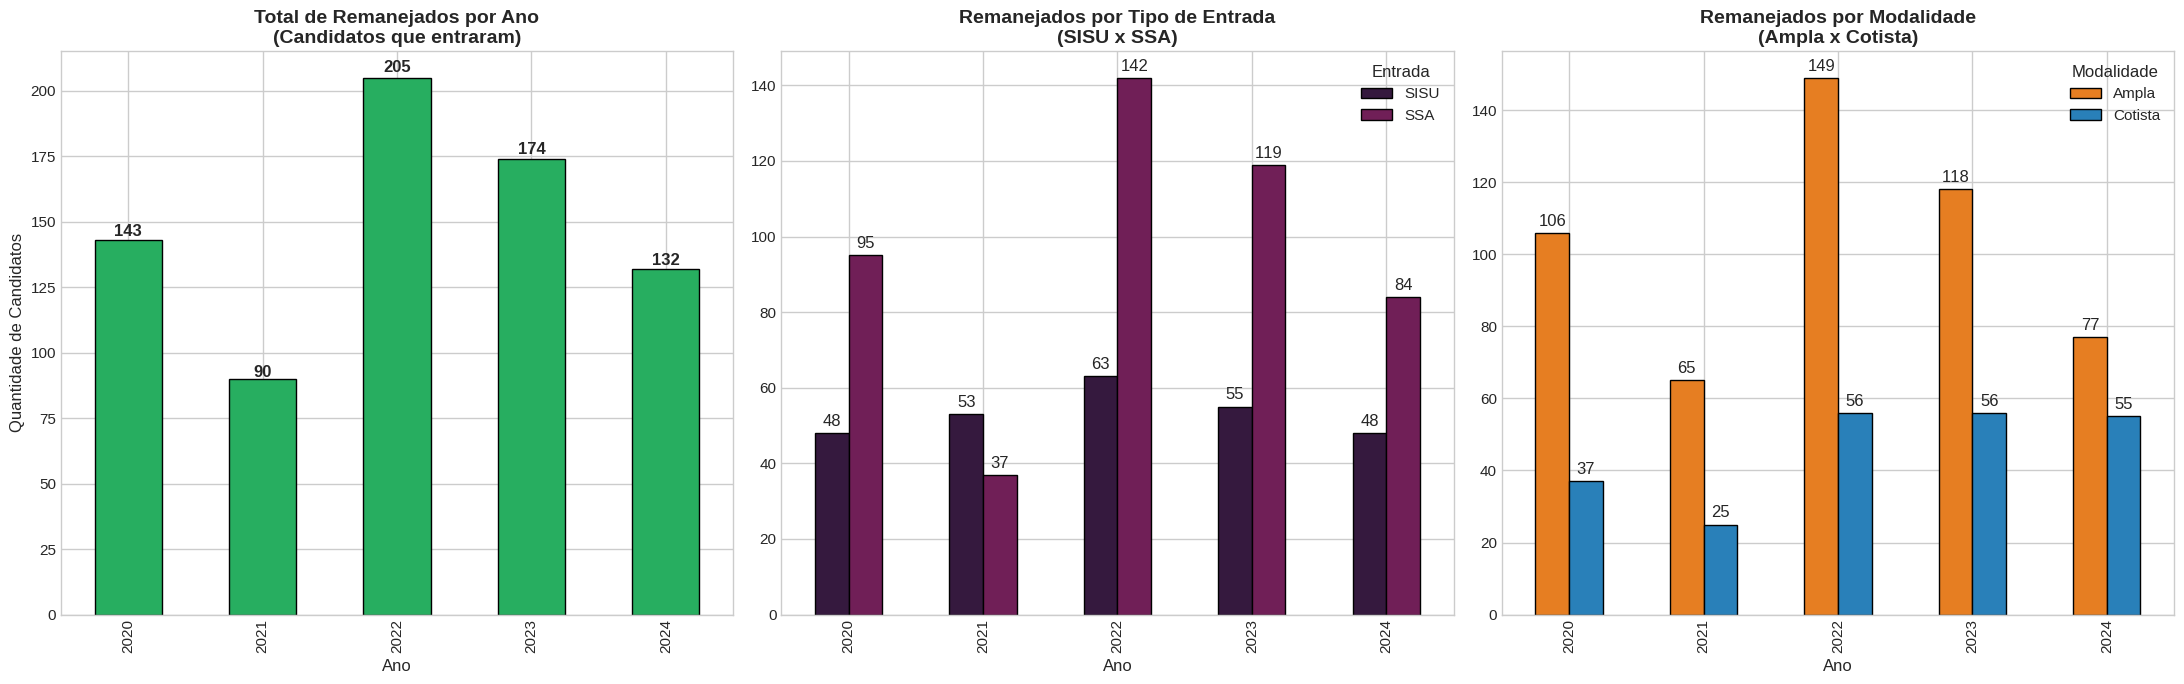

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração visual profissional (mantendo o padrão)
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("rocket") # Paleta específica para Remanejamentos

def gerar_graficos_remanejamentos(dados):
    # Filtrar apenas os candidatos que foram efetivamente REMANEJADOS
    df_remanejados = dados[dados['Status_Resultado'] == 'REMANEJADOS'].copy()

    if df_remanejados.empty:
        print("Atenção: Não foram encontrados dados de 'REMANEJADO' para gerar os gráficos.")
        return

    # Criar figura com 3 subplots
    fig, axes = plt.subplots(1, 3, figsize=(22, 7))

    # --- GRÁFICO 1: TODOS (POR ANO) ---
    todos = df_remanejados.groupby('Ano').size()
    todos.plot(kind='bar', ax=axes[0], color='#27ae60', edgecolor='black')
    axes[0].set_title('Total de Remanejados por Ano', fontsize=14, fontweight='bold')
    axes[0].set_ylabel('Quantidade de Candidatos')
    axes[0].set_xlabel('Ano')
    for i, v in enumerate(todos):
        axes[0].text(i, v + (v*0.01), str(v), ha='center', fontweight='bold')

    # --- GRÁFICO 2: POR ENTRADA (SISU x SSA) ---
    por_entrada = df_remanejados.groupby(['Ano', 'Entrada']).size().unstack(fill_value=0)
    por_entrada.plot(kind='bar', ax=axes[1], edgecolor='black')
    axes[1].set_title('Remanejados por Tipo de Entrada\n(SISU x SSA)', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Ano')
    axes[1].legend(title='Entrada')
    for container in axes[1].containers:
        axes[1].bar_label(container, padding=3)

    # --- GRÁFICO 3: POR MODALIDADE (AMPLA x COTISTA) ---
    por_modalidade = df_remanejados.groupby(['Ano', 'Modalidade_Simples']).size().unstack(fill_value=0)
    por_modalidade.plot(kind='bar', ax=axes[2], color=['#e67e22', '#2980b9'], edgecolor='black')
    axes[2].set_title('Remanejados por Modalidade\n(Ampla x Cotista)', fontsize=14, fontweight='bold')
    axes[2].set_xlabel('Ano')
    axes[2].legend(title='Modalidade')
    for container in axes[2].containers:
        axes[2].bar_label(container, padding=3)

    plt.tight_layout()
    plt.show()

# Executar a geração dos gráficos de remanejamentos
# Assume que 'df' já passou pelo seu módulo de limpeza
gerar_graficos_remanejamentos(df)


 ANÁLISE DE NOTAS: ADMINISTRACAO


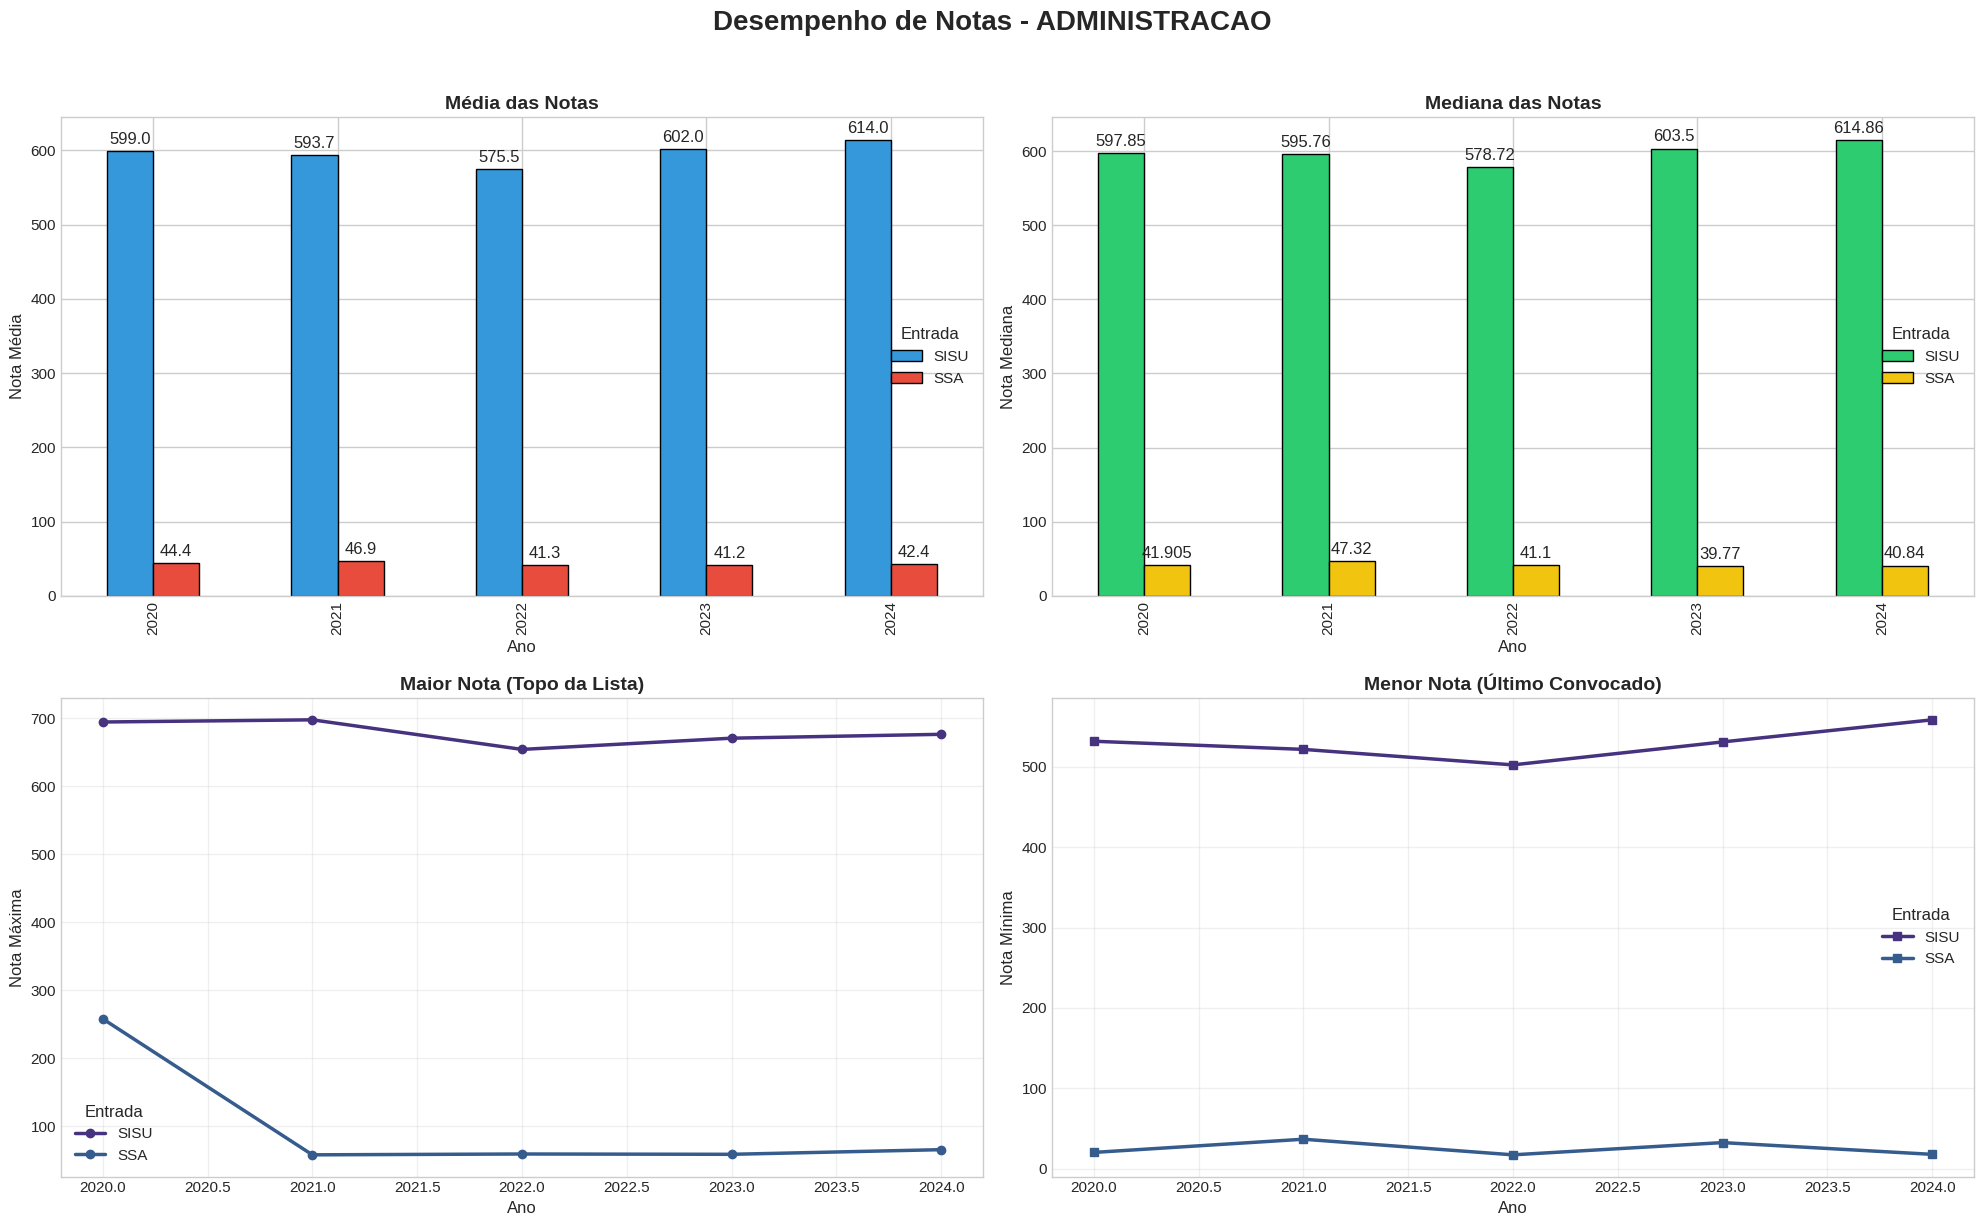


 ANÁLISE DE NOTAS: SISTEMA DE INFORMACAO


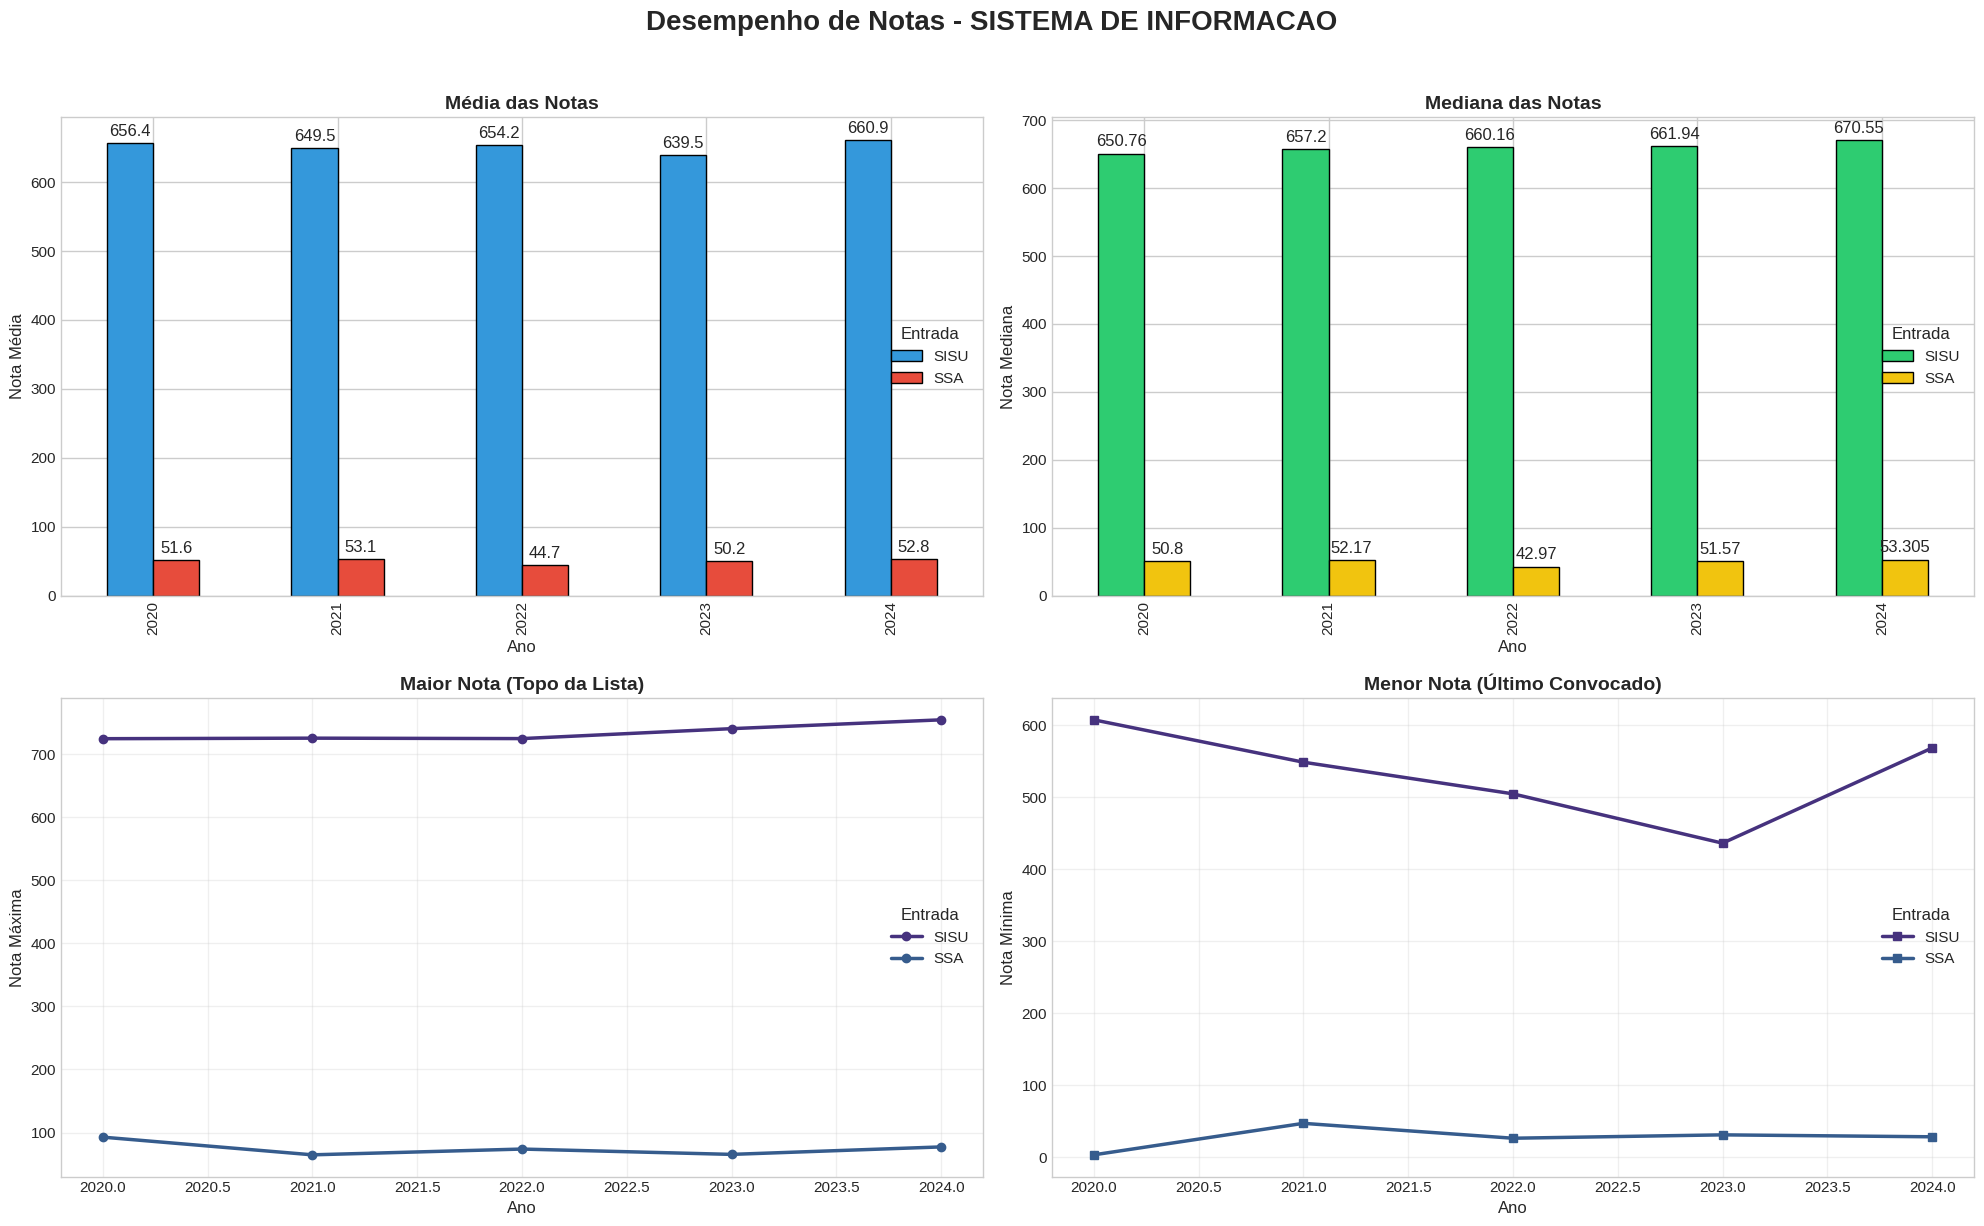

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração visual profissional
plt.style.use('seaborn-v0_8-whitegrid')

def gerar_graficos_notas_detalhado(dados):
    # Consideramos quem foi selecionado: CLASSIFICADO ou REMANEJADO
    df_selecionados = dados[dados['Status_Resultado'].isin(['CLASSIFICADO', 'REMANEJADOS'])].copy()

    if df_selecionados.empty:
        print("Atenção: Não foram encontrados dados de candidatos selecionados.")
        return

    # Lista de cursos únicos na base
    cursos = df_selecionados['Curso'].unique()

    for curso in cursos:
        df_curso = df_selecionados[df_selecionados['Curso'] == curso]

        print(f"\n{'='*30}")
        print(f" ANÁLISE DE NOTAS: {curso}")
        print(f"{'='*30}")

        # Criar figura com 2 linhas e 2 colunas para o curso atual
        fig, axes = plt.subplots(2, 2, figsize=(20, 12))
        fig.suptitle(f'Desempenho de Notas - {curso}', fontsize=20, fontweight='bold', y=1.02)

        # 1. MÉDIA DAS NOTAS
        media = df_curso.groupby(['Ano', 'Entrada'])['Nota'].mean().unstack()
        media.plot(kind='bar', ax=axes[0, 0], edgecolor='black', color=['#3498db', '#e74c3c'])
        axes[0, 0].set_title('Média das Notas', fontsize=14, fontweight='bold')
        axes[0, 0].set_ylabel('Nota Média')
        for container in axes[0, 0].containers:
            axes[0, 0].bar_label(container, fmt='%.1f', padding=3)

        # 2. MEDIANA DAS NOTAS
        mediana = df_curso.groupby(['Ano', 'Entrada'])['Nota'].median().unstack()
        mediana.plot(kind='bar', ax=axes[0, 1], edgecolor='black', color=['#2ecc71', '#f1c40f'])
        axes[0, 1].set_title('Mediana das Notas', fontsize=14, fontweight='bold')
        axes[0, 1].set_ylabel('Nota Mediana')
        for container in axes[0, 1].containers:
            axes[0, 1].bar_label(container, padding=3)

        # 3. MAIOR NOTA (MÁXIMA)
        maior = df_curso.groupby(['Ano', 'Entrada'])['Nota'].max().unstack()
        maior.plot(kind='line', ax=axes[1, 0], marker='o', linewidth=2.5)
        axes[1, 0].set_title('Maior Nota (Topo da Lista)', fontsize=14, fontweight='bold')
        axes[1, 0].set_ylabel('Nota Máxima')
        axes[1, 0].grid(True, alpha=0.3)

        # 4. MENOR NOTA (MÍNIMA / CORTE)
        menor = df_curso.groupby(['Ano', 'Entrada'])['Nota'].min().unstack()
        menor.plot(kind='line', ax=axes[1, 1], marker='s', linewidth=2.5)
        axes[1, 1].set_title('Menor Nota (Último Convocado)', fontsize=14, fontweight='bold')
        axes[1, 1].set_ylabel('Nota Mínima')
        axes[1, 1].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

# Executar a geração dos gráficos de notas separados por curso
# Assume que 'df' já passou pelo seu módulo de limpeza
gerar_graficos_notas_detalhado(df)